In [1]:
""" Create the mean saturation percentage value over all the ISIMIP model configurations, year 2025
"""
import os
from glob import glob
import netCDF4 as nc
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import rasterio as rio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_origin
import pandas as pd
from rasterio.fill import fillnodata

# Shared variables
lat_bounds = [23.0,54.5]
lon_bounds = [-125.5,-66.5]

# Use 20cm because HWSD2 data is complete that way
target_depth = 0.2

# 1. Process the ISIMIP soil moisture data

In [2]:
path_root = os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 'ISIMIP3b_soilmoist')
filelist = sorted(glob(path_root + '/*.nc'))

depth_dict = {}

for fp in filelist:
    filename = os.path.basename(fp)
    parts = filename.split('_')
    key = parts[0]

    # skip watergap2 because it is rooting depth aggregate,
    # cannot be mapped to 30cm
    if 'watergap2' in key:
        continue

    # skip CWatM because it is 1m at shallowest, we probably
    # want 30cm because the mixing depth isn't too deep
    if 'cwatm' in key:
        continue

    # do not revisit the same land model
    if key in depth_dict:
        continue

    with nc.Dataset(fp) as ds:
        depth_values = ds['depth'][:]
        depth_dict[key] = depth_values

print(depth_dict)

{'jules-es-vn6p3': masked_array(data=[0.05 , 0.225, 0.675, 2.   ],
             mask=False,
       fill_value=1e+20), 'jules-w2': masked_array(data=[0.1       , 0.25      , 0.64999998, 2.        ],
             mask=False,
       fill_value=1e+20), 'miroc-integ-land': masked_array(data=[2.50e-02, 1.50e-01, 6.25e-01, 1.50e+00, 2.50e+00,
                   3.50e+00, 4.50e+00, 5.50e+00, 6.50e+00, 7.50e+00,
                   8.50e+00, 9.50e+00, 5.50e+01],
             mask=False,
       fill_value=1e+20)}


/tmp/ipykernel_2512501/2070652768.py:50: RuntimeWarning: Mean of empty slice
  soilmoist_avg = np.nanmean(soilmoist_2025, axis=0)  # now dimensions: depth, lat, lon
/tmp/ipykernel_2512501/2070652768.py:80: UserWarning: The following kwargs were not used by contour: 'shading'
  cf = ax.contourf(lons_subset, lats_subset, interp_subset_collection[filename],


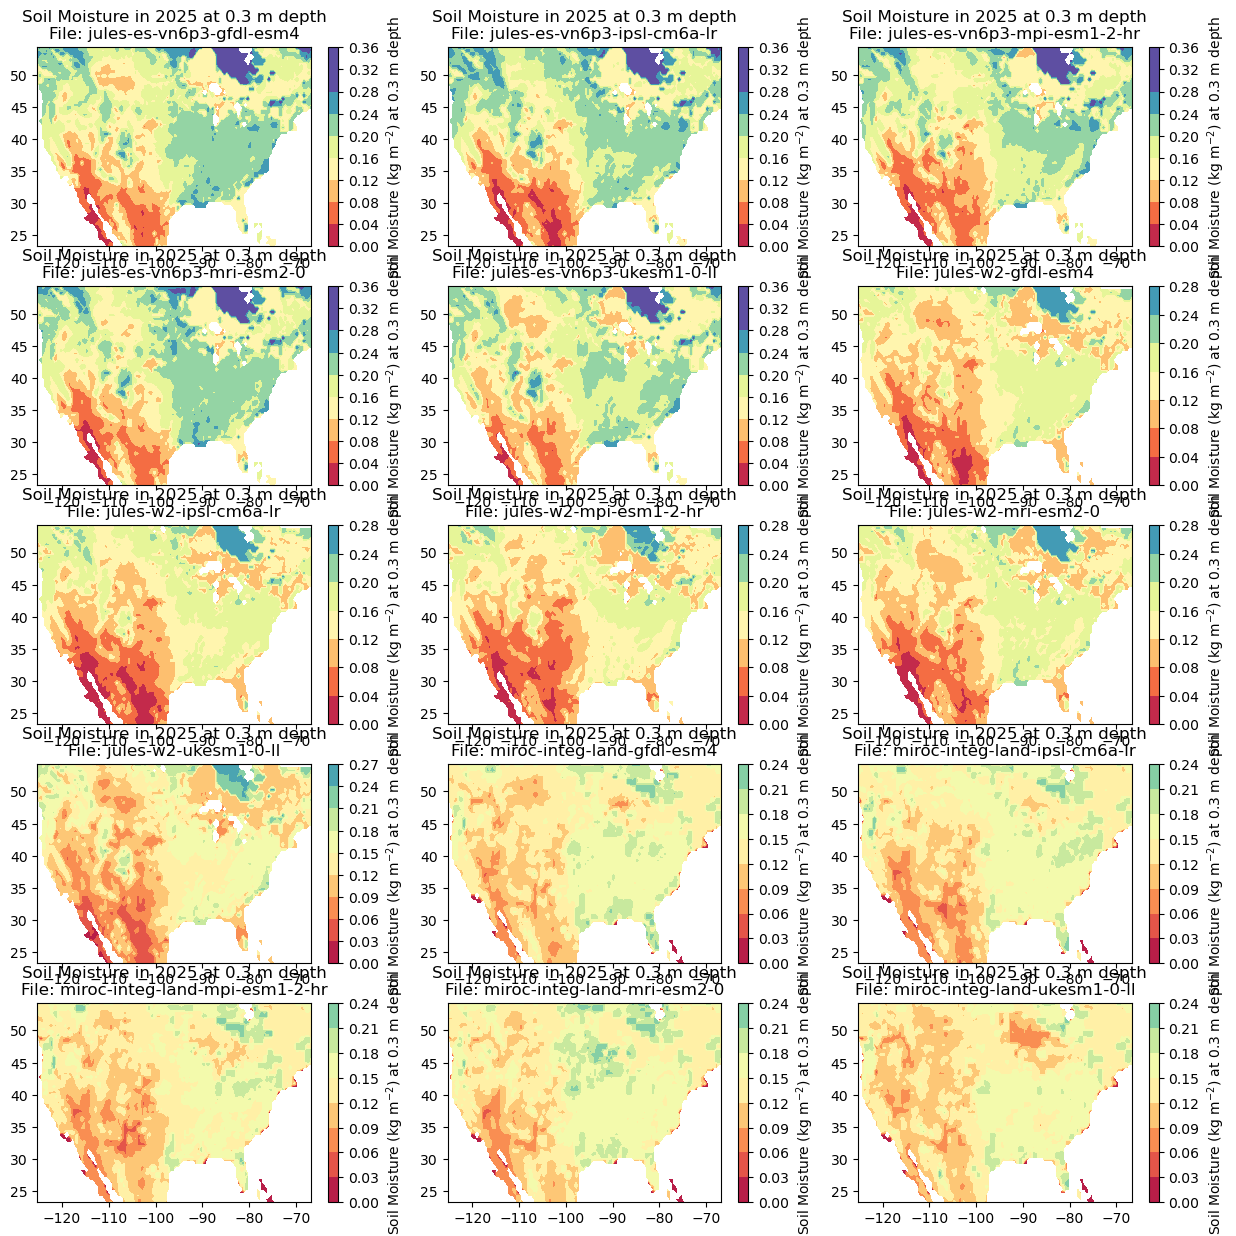

In [3]:
interp_subset_collection = {}
for fp in filelist:
    if 'watergap2' in fp or 'cwatm' in fp:
        continue

    filename = os.path.basename(fp)

    parts = filename.split('_')
    key = f'{parts[0]}-{parts[1]}'

    ds = nc.Dataset(fp, 'r')

    # Extract variables
    time_var = ds.variables['time']
    soilmoist_var = ds.variables['soilmoist']
    depth_var = ds.variables['depth'][:]
    lat_var = ds.variables['lat'][:]
    lon_var = ds.variables['lon'][:]

    # Convert time variable to datetime objects using netCDF4.num2date
    time_units = time_var.units  # e.g., "days since 1601-01-01 00:00:00"
    time_calendar = time_var.calendar if hasattr(time_var, 'calendar') else "standard"
    times = nc.num2date(time_var[:], units=time_units, calendar=time_calendar)
    
    # Find indices corresponding to the year 2025
    # We'll assume that we want all time steps in 2025
    time_indices_2025 = [i for i, t in enumerate(times) if t.year == 2025]

    if not time_indices_2025:
        print(f"No time steps found for 2025 in file {fp}")
        ds.close()
        continue

    # Get indices within the bounding box using boolean masks
    lat_mask = (lat_var >= lat_bounds[0]) & (lat_var <= lat_bounds[1])
    lon_mask = (lon_var >= lon_bounds[0]) & (lon_var <= lon_bounds[1])
    
    # Apply the masks; assume soilmoist dimensions correspond to (lat, lon)
    lats_subset = lat_var[lat_mask]
    lons_subset = lon_var[lon_mask]

    # Extract soil moisture data for 2025 (dimensions: time, depth, lat, lon)
    soilmoist_2025 = soilmoist_var[time_indices_2025, :, :, :][:, :, lat_mask, 
                                                               :][:, :, :, lon_mask]

    # Compute the average over the time dimension (axis=0)
    # Make sure to mask out fill values (assumed to be 1.e+20f)
    fill_value = soilmoist_var._FillValue if hasattr(soilmoist_var, '_FillValue') else 1.e+20
    soilmoist_2025 = np.where(soilmoist_2025.data == fill_value, np.nan, soilmoist_2025.data)
    soilmoist_avg = np.nanmean(soilmoist_2025, axis=0)  # now dimensions: depth, lat, lon

    # Convert depth to interfaces using their middle
    depth_interfaces = np.insert(0.5*(depth_var[1:] + depth_var[:-1]), 0, 0)
    depth_thicknesses = np.diff(depth_interfaces)

    # Index to the layers that at least partially covers 0-0.3m
    useful_layers = np.where(depth_interfaces < target_depth)[0]

    # Linearly combine the useful layers: kg m-2 => m3/m3
    for i in useful_layers:
        if depth_interfaces[i+1] <= target_depth:
            weight = 1
        else:
            weight = (target_depth - depth_interfaces[i]) / depth_thicknesses[i]

        if i == 0:
            interp_subset = soilmoist_avg[i, :, :] * weight
        else:
            interp_subset = interp_subset + soilmoist_avg[i, :, :] * weight
    interp_subset = interp_subset / target_depth * 0.001
    interp_subset_collection[key] = interp_subset

    ds.close()


# Plot the interpolated soil moisture at 0.3 m depth
fig, axes = plt.subplots(5, 3, figsize = (15, 15))
for i, filename in enumerate(list(interp_subset_collection.keys())):
    ax = axes.flat[i]
    cf = ax.contourf(lons_subset, lats_subset, interp_subset_collection[filename], 
                     shading='auto', cmap = 'Spectral', vmin = 0, vmax = 0.3)
    plt.colorbar(cf, ax = ax, label="Soil Moisture (kg m$^{-2}$) at 0.3 m depth")
    #ax.set_xlabel("Longitude")
    #ax.set_ylabel("Latitude")
    ax.set_title(f"Soil Moisture in 2025 at 0.3 m depth\nFile: {filename}")

/tmp/ipykernel_2512501/1323091501.py:9: UserWarning: The following kwargs were not used by contour: 'shading'
  cf = ax.contourf(lons_subset, lats_subset, interp_subset_average,


Text(0.5, 1.0, 'Soil Moisture in 2025 at 0.3 m depth\nFile: miroc-integ-land-ukesm1-0-ll')

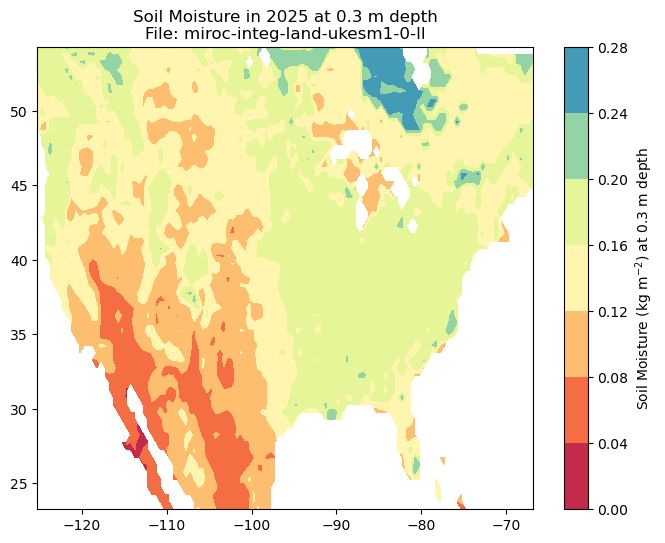

In [4]:
# Average
interp_subset_average = 0
for i, filename in enumerate(list(interp_subset_collection.keys())):
    interp_subset_average = interp_subset_average + interp_subset_collection[filename]
interp_subset_average = interp_subset_average / (i+1)


fig, ax = plt.subplots(figsize = (8, 6))
cf = ax.contourf(lons_subset, lats_subset, interp_subset_average, 
                 shading='auto', cmap = 'Spectral', vmin = 0, vmax = 0.3)
plt.colorbar(cf, ax = ax, label="Soil Moisture (kg m$^{-2}$) at 0.3 m depth")
#ax.set_xlabel("Longitude")
#ax.set_ylabel("Latitude")
ax.set_title(f"Soil Moisture in 2025 at 0.3 m depth\nFile: {filename}")

In [5]:
# Save to file
transform = from_origin(-125.5, 54.5, 0.5, 0.5)  # (lon_min, lat_max, pixel_width, pixel_height)
crs = rio.crs.CRS.from_epsg(4326)

# Create a new rasterio dataset
new_dataset = rio.open(
    os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'results', 'SM', 'SM_avg_2025.tif'),
    'w',
    driver='GTiff',
    height=interp_subset_average.shape[0],
    width=interp_subset_average.shape[1],
    count=1,
    dtype=np.float32,
    crs=crs,
    transform=transform,
    nodata = 1e20
)

new_dataset.write(np.where(np.isnan(interp_subset_average), 1e20, interp_subset_average), 1)

new_dataset.close()

# 2. Obtain the porosity values from HWSD2

Use 0-20cm, top band

In [6]:
path_hwsd = os.path.join(os.environ['PROJDIR'], 'Soil_Properties', 'intermediate', 'HWSD2')

with rio.open(os.path.join(path_hwsd, f'porosity_1.tif'), 'r') as h:
    porosity = h.read(1, masked = True)

    # get the source information
    src_transform = h.transform
    src_crs = h.crs

In [7]:
# Get the target info
with rio.open(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'results', 'SM', 
                           'SM_avg_2025.tif')) as tgt:
    target_profile = tgt.profile.copy()
    tgt_transform = tgt.transform
    tgt_crs = tgt.crs
    target_shape = (tgt.height, tgt.width)

# Prepare an array for the reprojected data (using same dtype as source)
destination = np.empty(shape = target_shape, dtype = porosity.dtype)

# Reproject from source to target using bilinear resampling
reproject(
    porosity,
    destination,
    src_transform=src_transform,
    src_crs=src_crs,
    dst_transform=tgt_transform,
    dst_crs=tgt_crs,
    resampling=Resampling.bilinear,
    src_nodata = 1e20,
    dst_nodata = 1e20
)


# Determine the nodata value (assume it's set in the target profile)
nodata = target_profile.get('nodata', None)
# Create a mask for gap cells (cells that equal nodata; adjust if your gaps are identified differently)
mask = (destination == 1e20) & ~np.isnan(interp_subset_average)

destination_filled = fillnodata(destination, mask=~mask, max_search_distance=10, 
                                smoothing_iterations=0)

# Write the reprojected data to a new GeoTIFF
with rio.open(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'results', 'SM',
                           'porosity_reproj.tif'), 'w', **target_profile) as dst:
    dst.write(destination_filled, 1)

# 3. Divide to get the saturation percentage

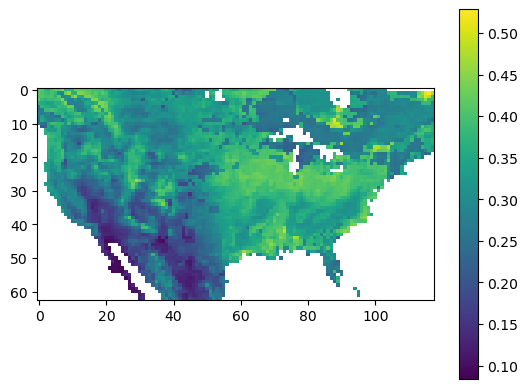

In [13]:
with rio.open(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'results', 'SM', 
                           'SM_avg_2025.tif')) as h:
    sm_avg_2025 = h.read(1, masked = True)
with rio.open(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'results', 'SM', 
                           'porosity_reproj.tif')) as h:
    porosity = h.read(1, masked = True)
    porosity = np.where(porosity.mask, np.nan, porosity.data)

saturation = sm_avg_2025 / porosity

# clip out tiny data at ocean edges
saturation = np.ma.masked_array(
    np.where(saturation.data < 1e-10, 1e20, saturation.data),
    (saturation.data < 1e-10) | saturation.mask
)


plt.imshow(saturation)
plt.colorbar()

transform = from_origin(-125.5, 54.5, 0.5, 0.5)  # (lon_min, lat_max, pixel_width, pixel_height)
crs = rio.crs.CRS.from_epsg(4326)

# Create a new rasterio dataset
new_dataset = rio.open(
    os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'results', 'SM', 'saturation_avg_2025.tif'),
    'w',
    driver='GTiff',
    height=saturation.shape[0],
    width=saturation.shape[1],
    count=1,
    dtype=np.float32,
    crs=crs,
    transform=transform,
    nodata = 1e20
)

new_dataset.write(np.where(saturation.mask, 1e20, saturation.data), 1)

new_dataset.close()

In [9]:
saturation

masked_array(
  data=[[0.41310980916023254, 0.413832426071167, 0.36734843254089355,
         ..., --, --, --],
        [0.41241851449012756, 0.40052109956741333, 0.38822856545448303,
         ..., 0.512873113155365, 0.5288097858428955, 0.4794333577156067],
        [0.40448805689811707, 0.40907561779022217, 0.3967849910259247,
         ..., 0.5047587156295776, 0.4777717590332031, 0.3875274658203125],
        ...,
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[False, False, False, ...,  True,  True,  True],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=1e+20,
  dtype=float32)